In [ ]:
!pip install --quiet --upgrade diffusers transformers accelerate invisible_watermark mediapy


In [ ]:
use_refiner = False


In [ ]:
import mediapy as media
import random
import sys
import torch
from diffusers import DiffusionPipeline


In [ ]:
# Load base model
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
)


if use_refiner:
    refiner = DiffusionPipeline.from_pretrained(
        "stabilityai/stable-diffusion-xl-refiner-1.0",
        text_encoder_2=pipe.text_encoder_2,
        vae=pipe.vae,
        torch_dtype=torch.float16,
        use_safetensors=True,
        variant="fp16"
    )
    refiner = refiner.to("cuda")
else:
    pipe = pipe.to("cuda")
    pipe.enable_model_cpu_offload()


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Prompt:	Fish swimming in a glass aquarium, vibrant underwater scene in mosaic painting style, highly sharp edges, detailed textures of scales and plants, tile-like fragmented patterns, bold outlines, strong shadow-light contrast, dramatic lighting, reflective glass, perfect for pencil sketch or stained glass effect
Seed:	2257404119272882108


""

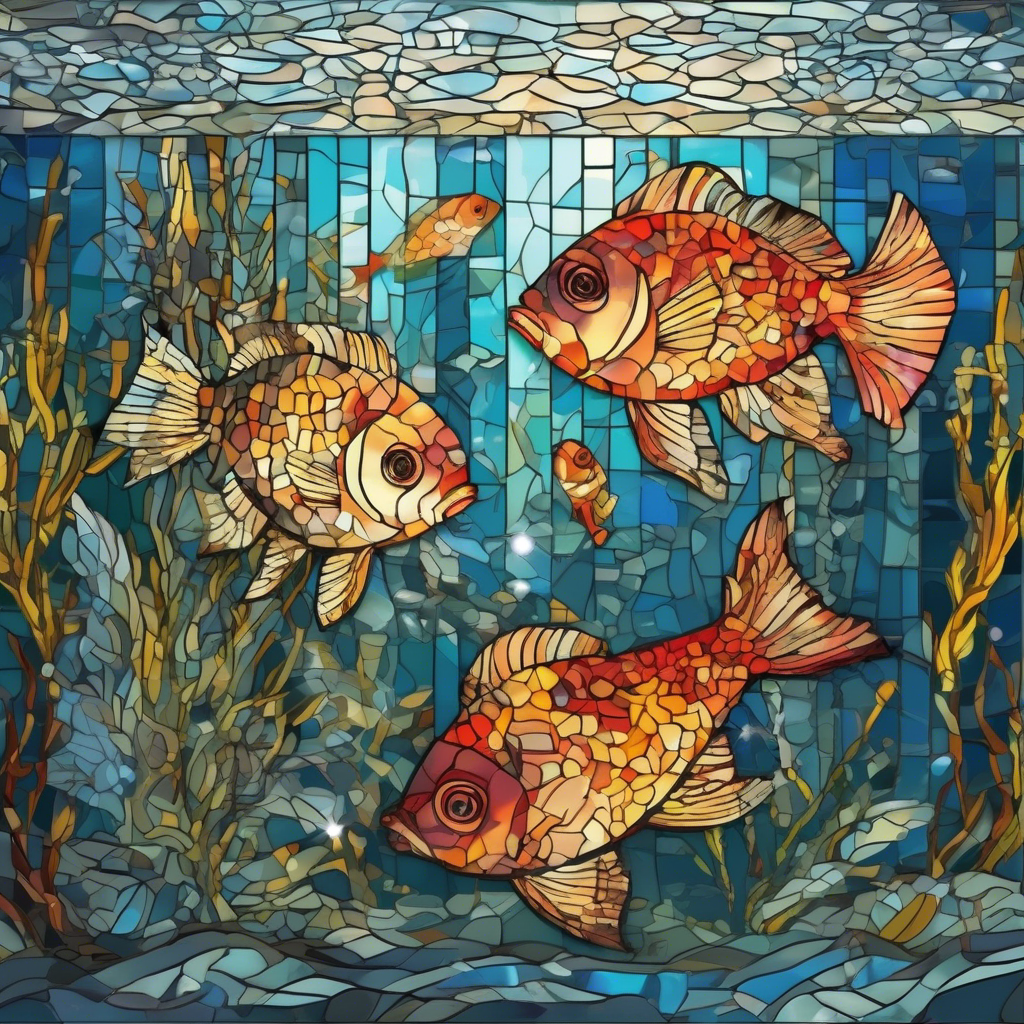

In [18]:
# Your custom prompt
prompt = "Fish swimming in a glass aquarium, vibrant underwater scene in mosaic painting style, highly sharp edges, detailed textures of scales and plants, tile-like fragmented patterns, bold outlines, strong shadow-light contrast, dramatic lighting, reflective glass, perfect for pencil sketch or stained glass effect"

#Set random seed
seed = random.randint(0, sys.maxsize)

# Generate the image
images = pipe(
    prompt=prompt,
    output_type="latent" if use_refiner else "pil",
    generator=torch.Generator("cuda").manual_seed(seed),
).images

# Refine if enabled
if use_refiner:
    images = refiner(prompt=prompt, image=images).images

# Save and display
print(f"Prompt:\t{prompt}\nSeed:\t{seed}")
media.show_images(images)
images[0].save("output.jpg")

In [ ]:
import cv2
import numpy as np
import PIL.Image
import tensorflow as tf
import os
import matplotlib.pyplot as plt



Processing Content Image 1: output.jpg


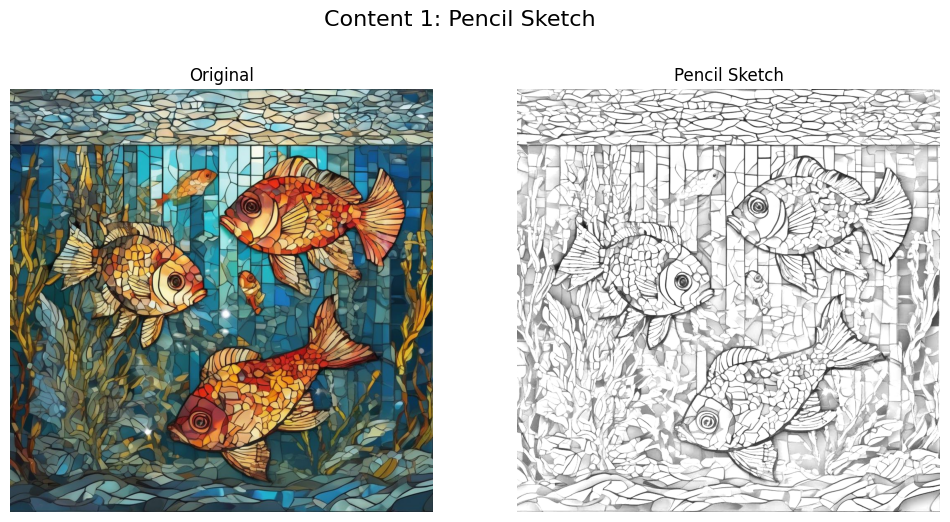

Saved pencil sketch image to: /content/sample_data/stylized_output.jpg


In [19]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import PIL

# Load image
def load_image(path_to_img, max_dim=1024):
    img = PIL.Image.open(path_to_img)
    img = img.convert('RGB')
    scale = max_dim / max(img.size)
    new_size = (int(img.size[0] * scale), int(img.size[1] * scale))
    img = img.resize(new_size, PIL.Image.LANCZOS)
    img = np.array(img) / 255.0
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = img[tf.newaxis, :]
    return img

# Pencil sketch effect
def pencil_sketch(image, intensity_scale=256):
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    inverted_gray = 255 - gray_image
    blurred = cv2.GaussianBlur(inverted_gray, (111,111), 0)
    sketch = cv2.divide(gray_image, 255 - blurred)
    sketch_rgb = cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)
    return sketch_rgb

# Display original and sketch side by side
def show_side_by_side(original_image, sketch_image, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(original_image)
    axes[0].set_title("Original")
    axes[0].axis('off')
    axes[1].imshow(sketch_image)
    axes[1].set_title("Pencil Sketch")
    axes[1].axis('off')
    plt.suptitle(title, fontsize=16)
    plt.show()

# List of content image paths
content_image_paths = ['output.jpg']

# Set your custom path for saving the stylized image
output_save_path = "/content/sample_data/stylized_output.jpg"  # Change this to your desired save path

# Process each image
for i, content_image_path in enumerate(content_image_paths, start=1):
    print(f"\nProcessing Content Image {i}: {content_image_path}")

    # Load and convert image
    content_image = load_image(content_image_path)[0].numpy()  # Remove batch dimension
    sketch_image = pencil_sketch(content_image, intensity_scale=1000)

    # Display side by side
    show_side_by_side(content_image, sketch_image, f"Content {i}: Pencil Sketch")

    # Convert to uint8 properly and save the pencil sketch
    sketch_uint8 = (np.clip(sketch_image, 0, 1) * 255).astype(np.uint8)
    Image.fromarray(sketch_uint8).save(output_save_path)
    print(f"Saved pencil sketch image to: {output_save_path}")


In [20]:
from skimage.metrics import structural_similarity as ssim
import cv2

# Load your generated pencil sketch and ground truth sketch as grayscale images
generated_sketch = cv2.imread('/content/output.jpg', cv2.IMREAD_GRAYSCALE)
ground_truth_sketch = cv2.imread('/content/sample_data/stylized_output.jpg', cv2.IMREAD_GRAYSCALE)

# Make sure both images have the same size (resize if necessary)
ground_truth_sketch = cv2.resize(ground_truth_sketch, (generated_sketch.shape[1], generated_sketch.shape[0]))

# Compute SSIM
score, diff = ssim(generated_sketch, ground_truth_sketch, full=True)
print(f"SSIM Score: {score:.4f}")


SSIM Score: 0.5879
